Fuente: Arial a 20 pt
150,586 alumnos (edades 8-15) | cache -> descriptive\cache/
132,577 alumnos en los cursos dibujados (8-12 años), mediana de 28 statements por alumno
panel de error:  132,577 alumnos (todos)
panel de tiempo: 126,539 alumnos (6,038 fuera por tener menos de 5 respuestas correctas)

 age   curso  alumnos_err  err_q1  err_med  err_q3  alumnos_rt  rt_q1  rt_med  rt_q3
   8     3.º        30500   14.89    34.48   72.73       27543   4.18    5.17   6.55
   9     4.º        31751    7.50    16.13   35.71       30638   3.57    4.23   5.22
  10     5.º        28845    5.56    12.50   30.00       27794   2.90    3.39   4.08
  11     6.º        29892    4.35     9.52   20.69       29188   2.66    3.08   3.67
  12 1.º ESO        11589    4.17     8.89   17.24       11376   2.55    2.96   3.55
-> plots/a998_estadisticas_curso_a_curso.png y .pdf (fondo transparente)


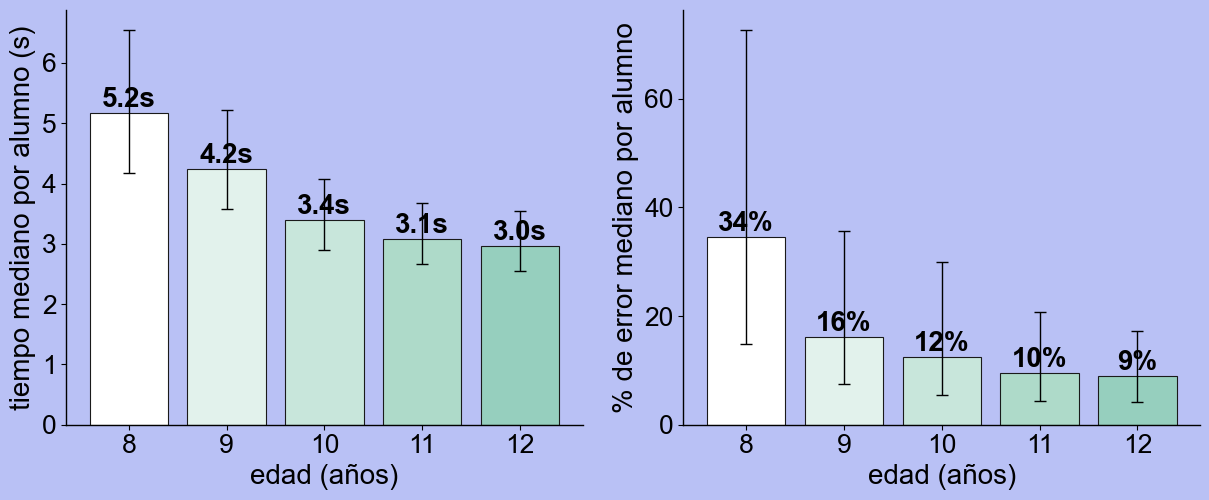

-> plots/a998_solapamiento_curso_a_curso.png y .pdf (fondo transparente)


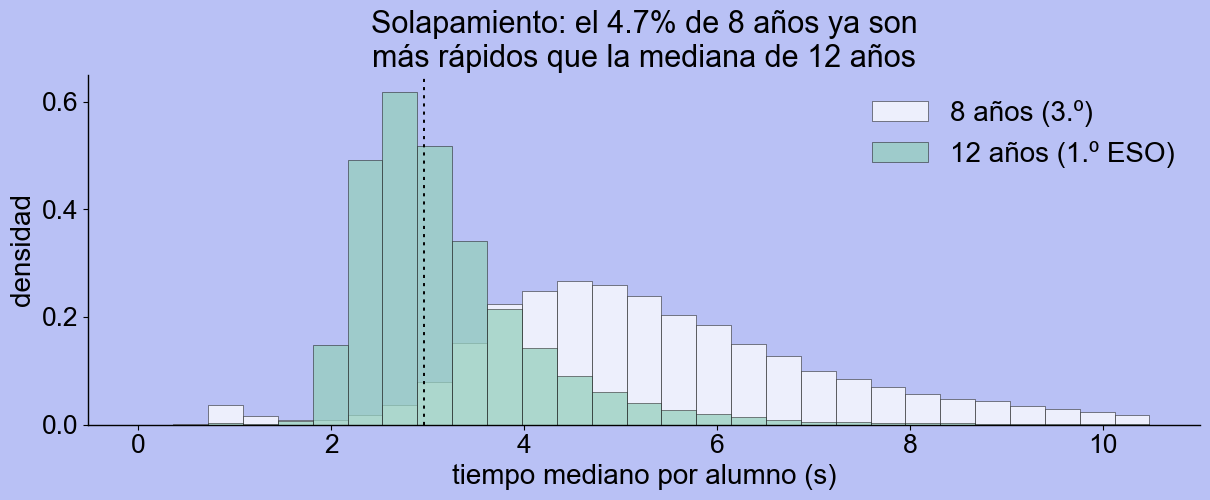


mediana de 12 años = 2.96 s | 4.7% de los 27,543 alumnos de 8 años están por debajo


In [4]:
# =============================================================================
# Estadísticas curso a curso (A998, España, ES_2025)
# =============================================================================
# Reproduce la figura `estadisticas_curso_a_curso.png` de inicial.ipynb, con tres
# cambios: sale de A998 en lugar de la zona Fluency, el texto está en castellano
# y el panel de solapamiento se guarda como figura APARTE. inicial.ipynb no se
# toca: queda como registro de lo que ya se hizo.
#
# POR QUÉ UNA QUERY NUEVA: la figura original leía
# `queries/student_rt_by_age.csv` (zona Fluency, sin query recuperable y ausente
# del repo nuevo, así que la celda original ya no se puede ejecutar). La query
# equivalente para A998 es `queries/a998_student_speed_accuracy_by_age.sql`.
#
# NO ES EL MISMO CONSTRUCTO que la figura de Fluency, y conviene decirlo si las
# dos acaban en el mismo documento: Fluency da un segundo intento, así que su
# tasa de error es de primer intento y su TR también. A998 es una sola pasada:
#   tasa de error = (Incorrect + Help) / n
#   TR mediano    = mediana de statement_seconds_spent SOLO sobre respuestas
#                   correctas (decisión del 2026-07-29)
# Aun así los dos coinciden bastante: la versión Fluency daba 5,2 s / 30% a los
# 8 años y 2,8 s / 8% a los 12; A998 da 5,17 s / 29,4% y 2,96 s / 8,7%.
#
# CURSOS (d_courses, ES_2025): edad 8 = 3.º Primaria, 9 = 4.º, 10 = 5.º,
# 11 = 6.º, 12 = 1.º ESO. La comparación 8 vs 12 de la figura original cruza por
# tanto la frontera Primaria-Secundaria.
#
# CUIDADO con el nivel de la tasa de error: A998 corrige mientras el alumno
# escribe y registra la primera tecla errónea como respuesta, así que el nivel
# está inflado (el suelo mecánico está sobre el 20%, no en cero). El orden entre
# cursos no se ve afectado, que es lo que esta figura defiende.
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

HERE = Path.cwd()          # descriptive/ (ejecutar el notebook desde su carpeta)
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # raíz del repo -- ahí viven databricks_connector.py y cached_query.py
sys.path.insert(0, str(ROOT))
from cached_query import cached_query      # SIEMPRE después de sys.path.insert
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

CACHE_DIR = HERE / "cache"
SQL_PATH = HERE / "queries" / "a998_student_speed_accuracy_by_age.sql"

AGES = [8, 9, 10, 11, 12]                  # como la figura original
AGE_GRADE = {8: "3.º", 9: "4.º", 10: "5.º", 11: "6.º", 12: "1.º ESO"}

# Fuente: la primera de la lista que esté instalada de verdad. Helvetica casi
# nunca lo está (en Windows nunca; matplotlib solo trae DejaVu Sans), y pedirla
# a ciegas deja un warning y un fallback silencioso. Arial y Liberation/Nimbus
# Sans son metric-compatibles con Helvetica.
FONT_PREF = ["Helvetica", "Helvetica Neue", "Arial", "Liberation Sans",
             "Nimbus Sans", "Calibri", "DejaVu Sans"]
_installed = {f.name for f in mpl.font_manager.fontManager.ttflist}
FONT = next((f for f in FONT_PREF if f in _installed), "DejaVu Sans")

# Tamaño de letra: un póster se mira de lejos, así que todo va grande. Se
# escala desde un solo número -- sube FONT_BASE y crece todo a la vez, sin
# tocar ninguna llamada de dibujo (ningún fontsize= suelto en el código de
# abajo, precisamente para que este mando sirva de algo).
FONT_BASE = 20
mpl.rcParams.update({"pdf.fonttype": 42, "svg.fonttype": "none",   # texto editable
                     "font.family": FONT,
                     "font.size": FONT_BASE,
                     "axes.titlesize": FONT_BASE + 2,
                     "axes.labelsize": FONT_BASE,
                     "xtick.labelsize": FONT_BASE - 1,
                     "ytick.labelsize": FONT_BASE - 1,
                     "legend.fontsize": FONT_BASE,
                     "text.color": "black", "axes.labelcolor": "black",
                     "xtick.color": "black", "ytick.color": "black"})
print(f"Fuente: {FONT} a {FONT_BASE} pt")

stu = cached_query(SQL_PATH, CACHE_DIR)
print(f"{len(stu):,} alumnos (edades 8-15) | cache -> {CACHE_DIR.relative_to(ROOT)}/")

d = stu[stu["classroom_course_age"].isin(AGES)].copy()
print(f"{len(d):,} alumnos en los cursos dibujados ({AGES[0]}-{AGES[-1]} años), "
      f"mediana de {d['n'].median():.0f} statements por alumno")

# LOS DOS PANELES TIENEN DENOMINADORES DISTINTOS, y es a propósito.
# El panel de error usa a TODOS los alumnos: la tasa de error está definida sin
# necesidad de ninguna respuesta correcta. El panel de tiempo necesita respuestas
# correctas para tener mediana, así que exige MIN_CORRECT.
# Filtrar el panel de error por n_correct sería quitarle justo los alumnos que
# más fallan: medido, la mediana de error a los 8 años pasa de 34,5% a 29,4%,
# 5,1 pp de sesgo optimista, y el sesgo cae a 0,2-0,7 pp en los cursos mayores.
MIN_CORRECT = 5
rt_ok = (d["n_correct"] >= MIN_CORRECT) & d["median_rt"].notna()
print(f"panel de error:  {len(d):,} alumnos (todos)")
print(f"panel de tiempo: {rt_ok.sum():,} alumnos "
      f"({(~rt_ok).sum():,} fuera por tener menos de {MIN_CORRECT} respuestas correctas)")

# Mediana + Q1-Q3 por curso. Cada alumno pesa lo mismo: son cuantiles de la
# distribución de alumnos, no medias ponderadas por intentos.
q1, q3 = lambda s: s.quantile(.25), lambda s: s.quantile(.75)
summ = (d.groupby("classroom_course_age")
          .agg(alumnos_err=("err_pct", "size"),
               err_q1=("err_pct", q1), err_med=("err_pct", "median"), err_q3=("err_pct", q3))
          .join(d[rt_ok].groupby("classroom_course_age")
                  .agg(alumnos_rt=("median_rt", "size"),
                       rt_q1=("median_rt", q1), rt_med=("median_rt", "median"),
                       rt_q3=("median_rt", q3)))
          .reset_index().rename(columns={"classroom_course_age": "age"}))
summ["curso"] = summ["age"].map(AGE_GRADE)
print()
print(summ[["age", "curso", "alumnos_err", "err_q1", "err_med", "err_q3",
            "alumnos_rt", "rt_q1", "rt_med", "rt_q3"]].round(2).to_string(index=False))

# Colores. "poster" = rampa de blanco (3.º) a verde menta #96CFBE (1.º ESO),
# pensada para leerse sobre el fondo lila del póster; "original" = el RdYlGn de
# la figura de inicial.ipynb, para comparar con lo que ya había.
#
# Los cinco pasos de la rampa son suaves a propósito y no pasa nada: en los dos
# paneles de barras el curso ya está en el eje X, así que el color es redundante
# y solo tiene que resultar agradable. Donde el color SÍ carga la información es
# en la figura del solapamiento, y allí se usan los dos extremos -- blanco
# contra menta -- que se distinguen sin problema.
#
# El filete oscuro va en todas las barras: sin él, la barra blanca desaparece
# del todo si el PNG transparente se abre sobre un fondo blanco.
PALETA = "poster"
VERDE_MENTA = "#96CFBE"
if PALETA == "poster":
    COLS = dict(zip(AGES, ["#ffffff", "#e2f2ec", "#c8e6db", "#aedac9", VERDE_MENTA]))
else:
    _cm = plt.cm.RdYlGn
    COLS = {a: _cm((a - min(AGES)) / (max(AGES) - min(AGES))) for a in AGES}

BAR_EDGE = "#1a1a1a"
LILA_POSTER = "#b9c1f5"        # solo para la vista previa dentro del notebook
PREVIEW_SOBRE_LILA = True      # nunca afecta al fichero guardado


def _clean(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("bottom", "left"):
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1)


def _save(fig, name):
    """Fondo transparente: figura y ejes sin color de fondo Y transparent=True
    en savefig -- hacen falta las tres cosas para que el PNG salga con canal
    alfa. El texto es negro, o sea que cuenta con un fondo claro."""
    fig.patch.set_alpha(0)
    for ax in fig.axes:
        ax.patch.set_alpha(0)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(HERE / "plots" / f"{name}.{ext}", dpi=300,
                    bbox_inches="tight", transparent=True)
    print(f"-> plots/{name}.png y .pdf (fondo transparente)")
    # El fichero ya está guardado. Esto solo pinta el fondo de la vista previa
    # con el lila del póster, para verlo como quedará: sobre el fondo blanco del
    # notebook, la barra blanca de 3.º no se ve.
    if PREVIEW_SOBRE_LILA:
        fig.patch.set_facecolor(LILA_POSTER)
        fig.patch.set_alpha(1)


# --- FIGURA 1: velocidad y precisión curso a curso --------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))

for ax, (col_med, col_q1, col_q3, ylab, fmt) in zip(axes, [
    ("rt_med", "rt_q1", "rt_q3", "tiempo mediano por alumno (s)", "{:.1f}s"),
    ("err_med", "err_q1", "err_q3", "% de error mediano por alumno", "{:.0f}%"),
]):
    yerr = [summ[col_med] - summ[col_q1], summ[col_q3] - summ[col_med]]
    ax.bar(summ["age"], summ[col_med], yerr=yerr, capsize=4,
           color=[COLS[a] for a in summ["age"]], edgecolor=BAR_EDGE, linewidth=0.8,
           error_kw={"ecolor": "black", "elinewidth": 1})
    for x, v in zip(summ["age"], summ[col_med]):
        ax.text(x, v, fmt.format(v), ha="center", va="bottom",
                fontweight="bold", color="black")
    ax.set_xlabel("edad (años)")
    ax.set_ylabel(ylab)
    ax.set_xticks(AGES)
    _clean(ax)

# axes[0].set_title("Velocidad: tiempo de respuesta")
# axes[1].set_title("Precisión: porcentaje de error")
_save(fig, "a998_estadisticas_curso_a_curso")
plt.show()

# --- FIGURA 2: solapamiento entre el curso más joven y el más mayor ---------
# La barra de error de la figura 1 ya avisa de que las distribuciones se pisan;
# esto lo hace explícito. El número del título es la fracción de alumnos del
# curso más joven que ya son más rápidos que el alumno mediano del más mayor.
YOUNG, OLD = min(AGES), max(AGES)
rt = d[rt_ok]                                   # mismo subconjunto que el panel de tiempo
rt_young = rt.loc[rt["classroom_course_age"] == YOUNG, "median_rt"]
rt_old = rt.loc[rt["classroom_course_age"] == OLD, "median_rt"]
rt_med_old = rt_old.median()
pct = (rt_young < rt_med_old).mean() * 100

fig2, ax = plt.subplots(figsize=(12.5, 5.4))
bins = np.linspace(0, rt["median_rt"].quantile(.99), 30)
ax.hist(rt_young, bins=bins, density=True, color=COLS[YOUNG], alpha=.75,
        edgecolor=BAR_EDGE, linewidth=0.5,
        label=f"{YOUNG} años ({AGE_GRADE[YOUNG]})")
ax.hist(rt_old, bins=bins, density=True, color=COLS[OLD], alpha=.75,
        edgecolor=BAR_EDGE, linewidth=0.5,
        label=f"{OLD} años ({AGE_GRADE[OLD]})")
ax.axvline(rt_med_old, color="black", lw=1.4, ls=(0, (1.6, 2.6)))
ax.set_title(f"Solapamiento: el {pct:.1f}% de {YOUNG} años ya son\n"
             f"más rápidos que la mediana de {OLD} años")
ax.set_xlabel("tiempo mediano por alumno (s)")
ax.set_ylabel("densidad")
ax.legend(frameon=False)
_clean(ax)
_save(fig2, "a998_solapamiento_curso_a_curso")
plt.show()

print(f"\nmediana de {OLD} años = {rt_med_old:.2f} s | "
      f"{pct:.1f}% de los {len(rt_young):,} alumnos de {YOUNG} años están por debajo")


396,988 pack-sittings (todos los packs y edades) | cache -> descriptive\cache/
guarda del denominador (>=30s y >=3 ops): 384,397 de 396,988 (96.8%)
pack 39, edades 9-15, T1-T3: 244,355 sittings de 122,413 alumnos (2.0 sittings por alumno)

teclazos (<1.5s por operación y acierto <25%, Decisión #12): 5,454 sittings (2.23%)
  quitados: mediana 1.15s por operación al 9% de acierto -> -42.4 corregidas/min
  resto:    mediana 4.36s por operación al 88% de acierto
  su peso baja con la edad, así que NO filtrarlos exagera la pendiente: 9: 4.0%, 10: 3.0%, 11: 2.1%, 12: 1.2%, 13: 0.8%, 14: 0.4%, 15: 0.1%

mezcla de trimestres por edad (se agrupan en una sola distribución por edad; ojo con los 9 años, que son casi todo T3):
trimester                T1     T2     T3
classroom_course_age                     
9                        30     26  23475
10                    27088  25922  23987
11                    27877  26139  21981
12                    10675   8438   9122
13                     9

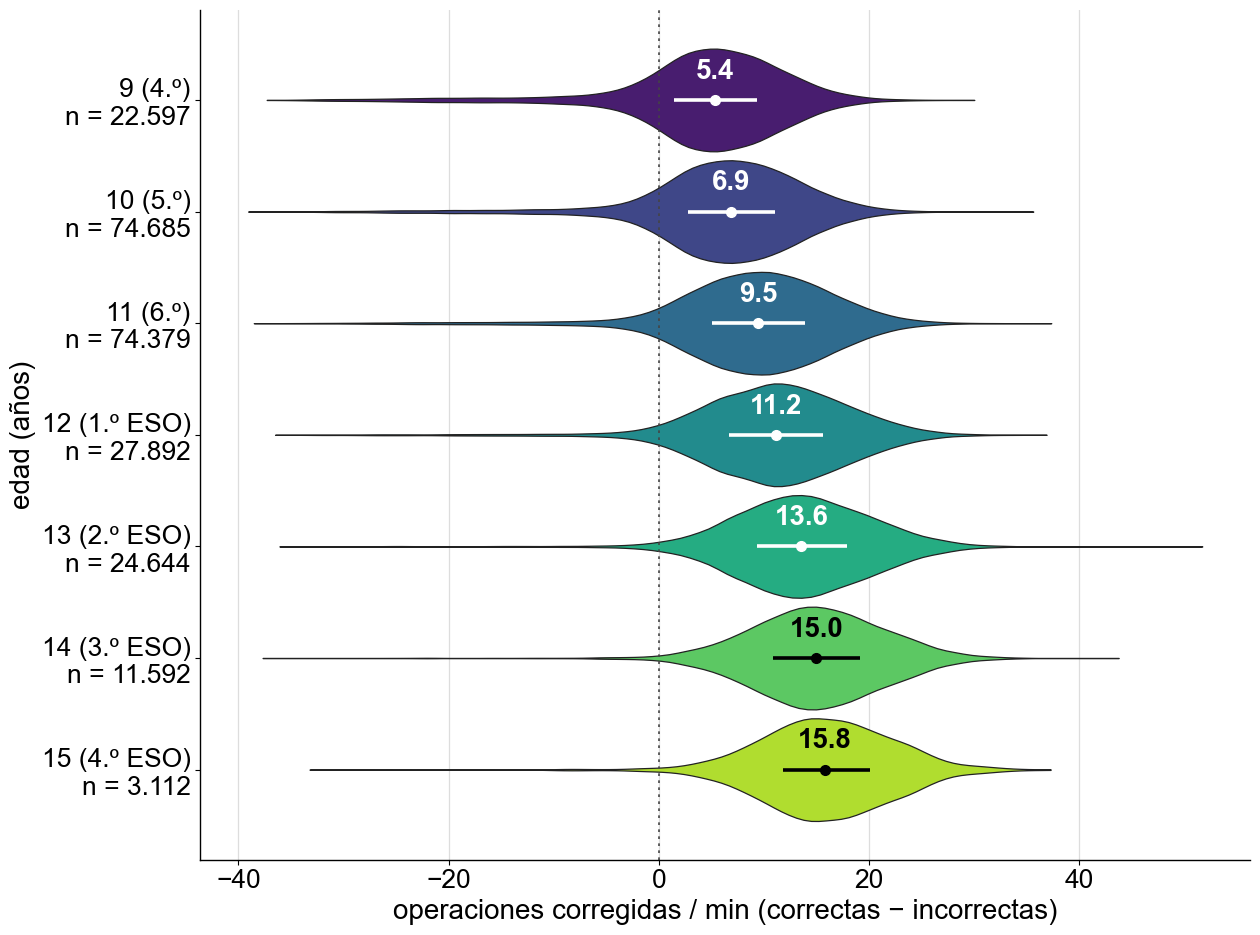

-> plots/a998_densidades_corregidas_min_por_edad.png y .pdf (fondo blanco, para presentación)


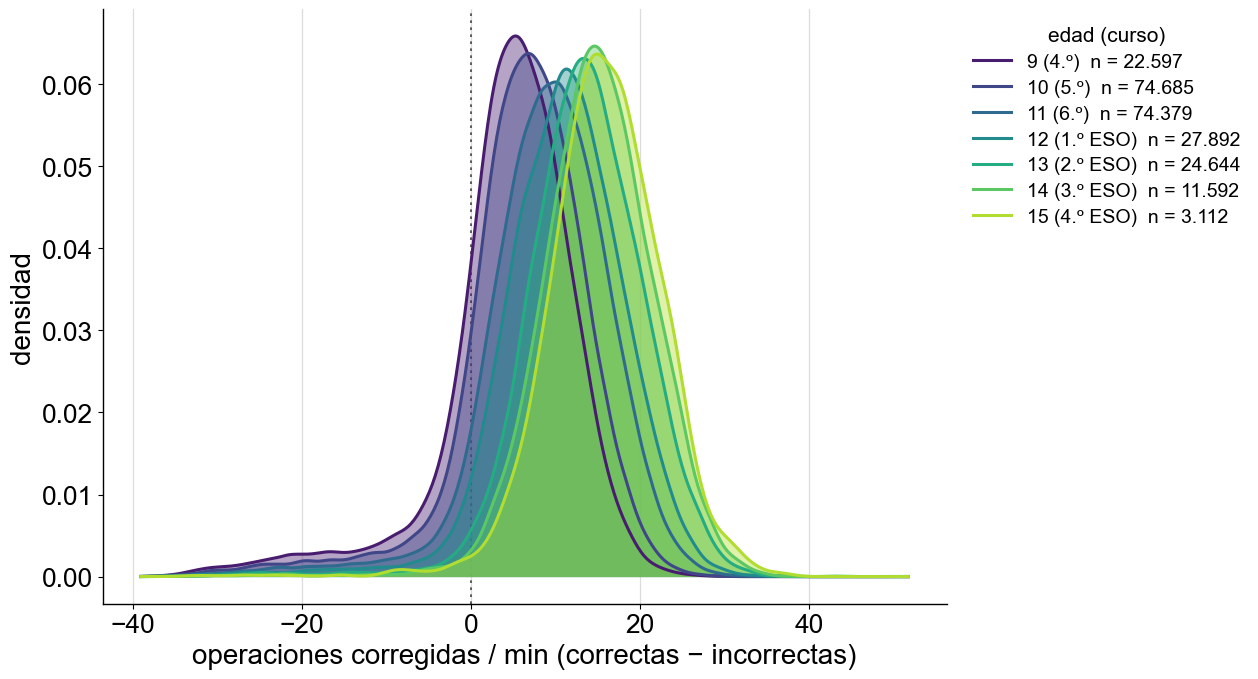

-> plots/a998_violin_corregidas_min_por_edad_sin_filtro.png y .pdf (fondo blanco, para presentación)


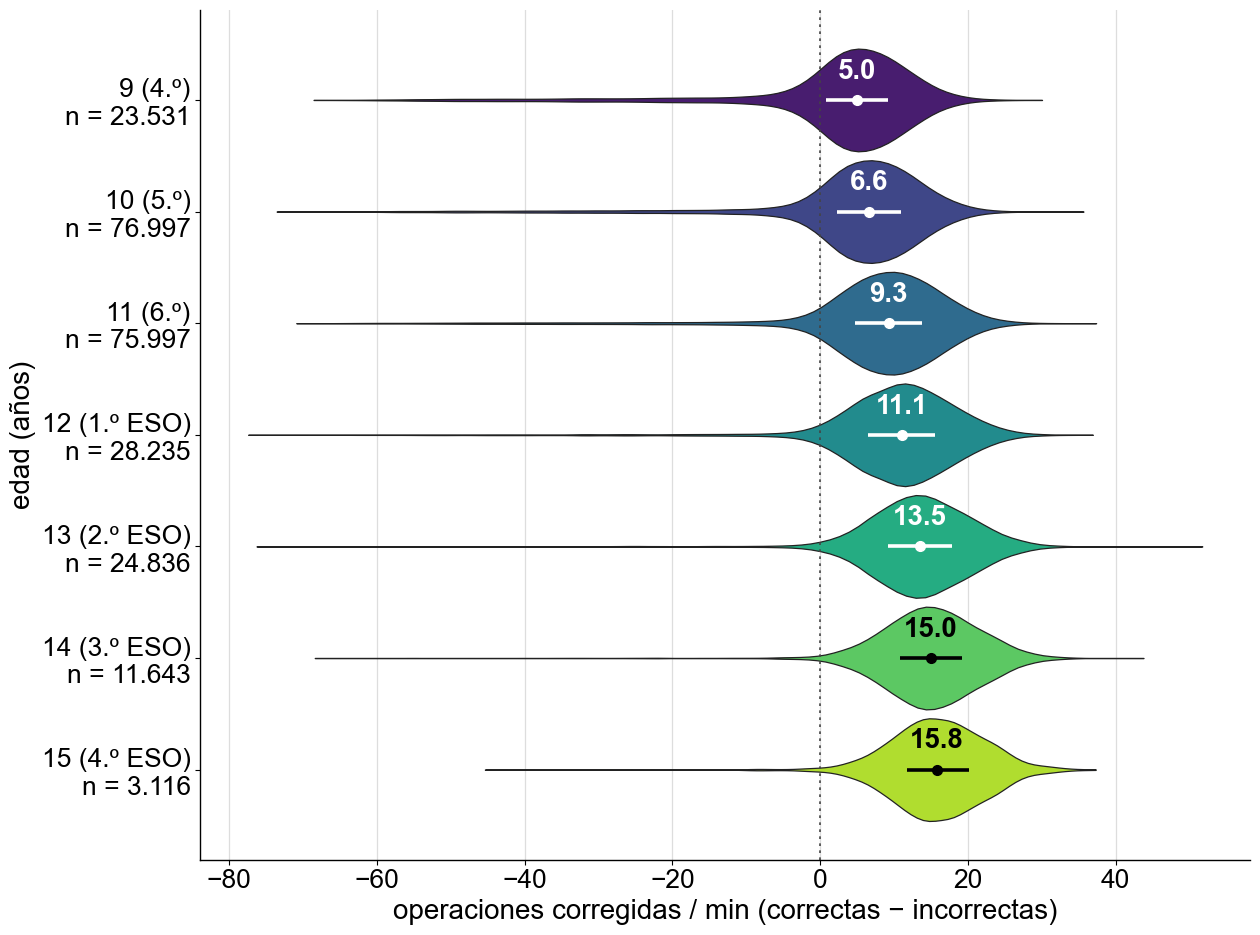

-> plots/a998_densidades_corregidas_min_por_edad_sin_filtro.png y .pdf (fondo blanco, para presentación)


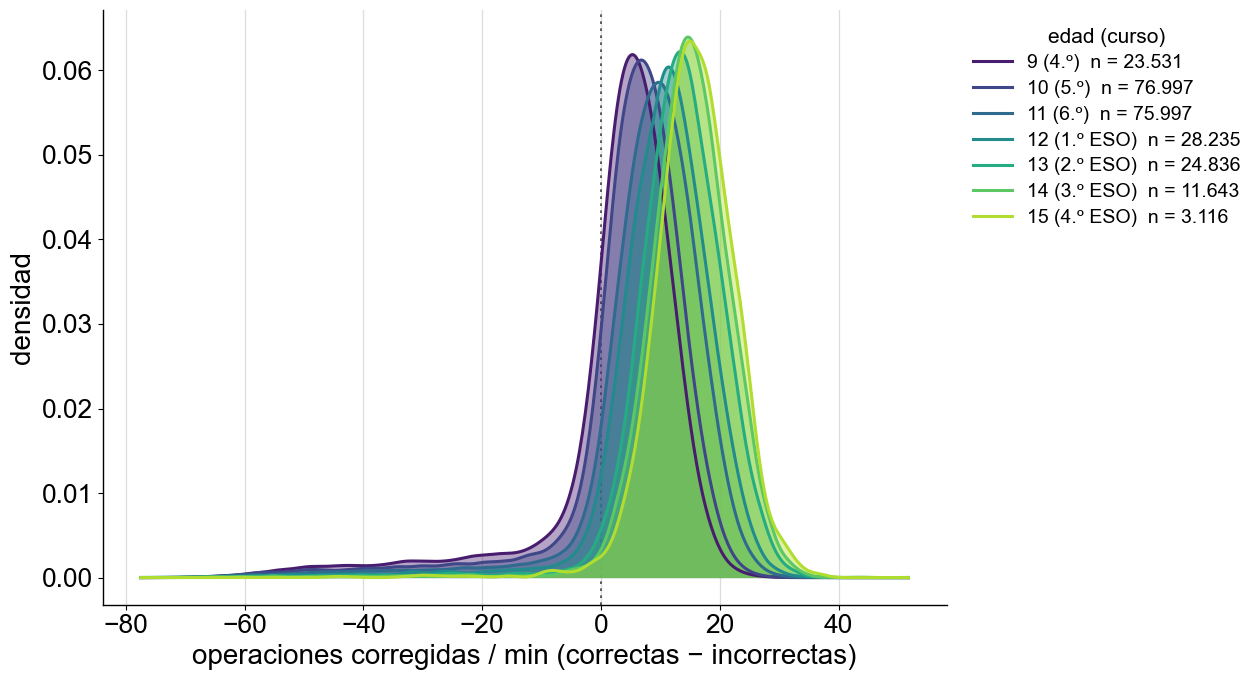


                      sittings  p10    q1  mediana    q3   p90  alumnos    curso
classroom_course_age                                                            
9                        22597 -3.8   1.4      5.4   9.4  12.9    22560      4.º
10                       74685 -1.5   2.8      6.9  11.1  14.7    33458      5.º
11                       74379  0.8   5.0      9.5  13.9  17.7    33529      6.º
12                       27892  2.8   6.7     11.2  15.6  19.6    12403  1.º ESO
13                       24644  5.6   9.4     13.6  17.9  21.9    11043  2.º ESO
14                       11592  7.0  10.9     15.0  19.2  23.1     5611  3.º ESO
15                        3112  8.0  11.8     15.8  20.1  23.8     1901  4.º ESO

Datos: A998, ES_2025, pack 39 (tablas 0-9, multiplicaciones y divisiones),
      trimestres T1-T3 agrupados, classroom_course_age (edad NOMINAL de curso, el
      warehouse no tiene fecha de nacimiento), una fila = un pack-sitting,
      corregidas = correctas − incorr

: 

In [ ]:
# =============================================================================
# Violines de OPERACIONES CORREGIDAS / MIN por edad (A998, España, ES_2025)
# =============================================================================
# PARA PRESENTACIÓN, no para el póster: paleta libre (viridis, un color por
# edad), fondo BLANCO y rejilla vertical suave, para que se lea proyectado.
# Por eso esta celda NO usa el `_save()` de la celda anterior (que guarda con
# fondo transparente y previsualiza sobre el lila del póster) sino su propio
# `_save_pres()`.
#
# Un violín por edad, apilados de 9 (arriba) a 15 años (abajo). Dentro de cada
# violín: punto = mediana, barra = Q1-Q3, línea de puntos vertical en el 0.
# REQUIERE haber ejecutado la celda anterior (de ahí vienen HERE, ROOT,
# CACHE_DIR, cached_query, _clean, FONT_BASE y los rcParams de fuente).
#
# NO HACE FALTA QUERY NUEVA: `queries/a998_corrected_ops_by_age.sql` ya devuelve
# esto (una fila por pack-sitting, con corrected_per_min y correct_per_min, edad
# de aula y de alumno, y trimestre), y su parquet ya está en `cache/`. Es la
# misma query que alimenta `corrected_operations_boxplot.ipynb`; aquí se
# reutiliza tal cual para no tener dos definiciones de la misma métrica.
#
# GRANO: una observación = un pack-sitting (los 120 s de reloj de un pack), NO
# un alumno. Son ~2 sittings por alumno, así que quien hizo dos pesa el doble;
# es el mismo grano que el boxplot del otro notebook, para que las dos figuras
# hablen de lo mismo.
#
# MÉTRICA (Decisión #7): corrected_per_min = (correctas − incorrectas) /
# (segundos contados / 60), descartando el primer statement (idx = 0) tanto del
# numerador como del denominador. Se descarta porque su tiempo incluye la cuenta
# atrás y la orientación inicial, y eso hunde sobre todo a los más pequeños.
#
# PACK 39 SOLO, Y POR ESO EDADES 9-15 (Decisión #4). El pack cambia con la edad,
# así que comparar edades a través de packs distintos confundiría dificultad con
# edad. El pack 39 (tablas 0-9, multiplicaciones y divisiones) es el único que
# cubre varias edades con volumen: 23.532 sittings a los 9 años y 3.554 a los
# 15 -- pero solo 29 a los 8, así que la edad 8 NO entra en esta figura. Los de
# 8 años hacen los packs 14/16/20; si hace falta la edad 8, va en una figura
# aparte diciendo que es otro pack (una figura por pack, como en el boxplot).
#
# TRIMESTRES AGRUPADOS, con un aviso: a los 9 años el pack 39 es casi todo T3
# (23.475 de 23.531 sittings), porque es cuando llegan a ese pack; a los 10 y 11
# está repartido entre T1-T3. Es decir, el violín de 9 años es "final de curso"
# y los demás son "todo el curso". La tabla de trimestres se imprime abajo.
#
# GUARDA DE TECLAZOS (Decisión #12, adaptada). Un ~2% de los sittings son
# ráfagas de teclado, no aritmética, y salen a −40 corregidas/min, estirando la
# cola izquierda hasta −77. Decisión #12 marca un sitting cuando su MEDIANA de
# statement_seconds_spent < 1,5 s Y su acierto < 25% (las dos cosas, para no
# marcar nunca a alguien rápido y acertado; 1,5 s es el antimodo de la
# distribución, no un número a ojo).
# Aquí se usa la MEDIA de segundos por operación (seconds_used / n_ops) porque
# esta query no devuelve la mediana por sitting -- para aplicar la Decisión #12
# exacta habría que añadirle una columna PERCENTILE(statement_seconds_spent,0.5)
# al .sql. Medido: la versión con media quita el 2,2% de los sittings, con
# mediana de 1,15 s por operación y 9% de acierto, y mueve la mediana de los 9
# años de 5,0 a 5,4 corregidas/min.
# Importa quitarlos porque su peso BAJA con la edad (4,0% a los 9 años → 0,1% a
# los 15): dejarlos dentro exagera la pendiente con la edad. Aun así se guarda
# también la versión sin filtrar, para poder ver qué se ha quitado.
AGE_COL_OPS  = "classroom_course_age"     # edad del aula, como el resto del notebook
VAL_COL_OPS  = "corrected_per_min"        # correctas − incorrectas, por minuto
PACK         = 39
AGES_OPS_MIN, AGES_OPS_MAX = 9, 15
TRI_ORDER    = ["T1", "T2", "T3"]

MIN_SECONDS  = 30.0    # guarda del denominador: un pack sano tiene ~115 s contados
MIN_OPS      = 3       # y al menos 3 operaciones después de tirar la primera
MIN_PER_VIOLIN = 100   # nunca dibujar un violín con un puñado de sittings
DIBUJAR_CONTROL = True # False -> solo las 2 figuras finales, sin las de control
RACING_SEC_PER_OP, RACING_ACC = 1.5, 0.25     # Decisión #12

AGE_GRADE_OPS = {9: "4.º", 10: "5.º", 11: "6.º", 12: "1.º ESO",
                 13: "2.º ESO", 14: "3.º ESO", 15: "4.º ESO"}

SQL_OPS = HERE / "queries" / "a998_corrected_ops_by_age.sql"
ops_raw = cached_query(SQL_OPS, CACHE_DIR)
print(f"{len(ops_raw):,} pack-sittings (todos los packs y edades) | "
      f"cache -> {CACHE_DIR.relative_to(ROOT)}/")

# --- guarda del denominador: una tasa explota si el denominador es diminuto ---
n0 = len(ops_raw)
ops = ops_raw[(ops_raw["seconds_used"] >= MIN_SECONDS) &
              (ops_raw["n_ops"] >= MIN_OPS)].copy()
print(f"guarda del denominador (>={MIN_SECONDS:g}s y >={MIN_OPS} ops): "
      f"{len(ops):,} de {n0:,} ({len(ops)/n0:.1%})")

ops = ops[(ops["activity_pack"] == PACK) & ops["trimester"].isin(TRI_ORDER)]
ops = ops.dropna(subset=[AGE_COL_OPS])
ops = ops[ops[AGE_COL_OPS].between(AGES_OPS_MIN, AGES_OPS_MAX)]
ops[AGE_COL_OPS] = ops[AGE_COL_OPS].astype(int)
print(f"pack {PACK}, edades {AGES_OPS_MIN}-{AGES_OPS_MAX}, T1-T3: {len(ops):,} sittings "
      f"de {ops['student_uuid'].nunique():,} alumnos "
      f"({len(ops)/ops['student_uuid'].nunique():.1f} sittings por alumno)")

# --- guarda de teclazos, medida y reportada antes de aplicarla ---------------
ops["seg_por_op"] = ops["seconds_used"] / ops["n_ops"]
ops["acierto"] = ops["n_correct"] / ops["n_ops"]
racing = (ops["seg_por_op"] < RACING_SEC_PER_OP) & (ops["acierto"] < RACING_ACC)
print(f"\nteclazos (<{RACING_SEC_PER_OP:g}s por operación y acierto <{RACING_ACC:.0%}, "
      f"Decisión #12): {racing.sum():,} sittings ({racing.mean():.2%})")
print(f"  quitados: mediana {ops.loc[racing, 'seg_por_op'].median():.2f}s por operación "
      f"al {ops.loc[racing, 'acierto'].median():.0%} de acierto "
      f"-> {ops.loc[racing, VAL_COL_OPS].median():.1f} corregidas/min")
print(f"  resto:    mediana {ops.loc[~racing, 'seg_por_op'].median():.2f}s por operación "
      f"al {ops.loc[~racing, 'acierto'].median():.0%} de acierto")
print("  su peso baja con la edad, así que NO filtrarlos exagera la pendiente: "
      + ", ".join(f"{a}: {racing[ops[AGE_COL_OPS] == a].mean():.1%}"
                  for a in range(AGES_OPS_MIN, AGES_OPS_MAX + 1)))

AGES_OPS = [a for a in range(AGES_OPS_MIN, AGES_OPS_MAX + 1)
            if (ops[AGE_COL_OPS] == a).sum() >= MIN_PER_VIOLIN]

# --- paleta de presentación --------------------------------------------------
# viridis recortada (0,08-0,88): se salta el amarillo casi invisible sobre
# blanco y el morado más oscuro, así los 7 colores se distinguen entre sí y
# ordenan la edad de un vistazo. Es perceptualmente uniforme y segura para
# daltonismo, que es lo que hace falta proyectado.
COLS_OPS = dict(zip(AGES_OPS,
                    plt.cm.viridis(np.linspace(0.08, 0.88, len(AGES_OPS)))))
BORDE = "#222222"
# Blanco o negro para la mediana y su etiqueta, según lo oscuro que sea el
# relleno: sobre el morado de los 9 años un punto negro no se ve.
def _contraste(rgba):
    r, g, b = rgba[:3]
    return "white" if (0.299 * r + 0.587 * g + 0.114 * b) < 0.55 else "black"

print(f"\nmezcla de trimestres por edad (se agrupan en una sola distribución "
      f"por edad; ojo con los 9 años, que son casi todo T3):")
print(pd.crosstab(ops[AGE_COL_OPS], ops["trimester"]).to_string())


def _save_pres(fig, name):
    """Guarda para presentación: fondo BLANCO (no transparente) y texto negro."""
    fig.patch.set_facecolor("white")
    fig.patch.set_alpha(1)
    for ax in fig.axes:
        ax.set_facecolor("white")
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(HERE / "plots" / f"{name}.{ext}", dpi=300,
                    bbox_inches="tight", facecolor="white")
    print(f"-> plots/{name}.png y .pdf (fondo blanco, para presentación)")


def violines_por_edad(d, nombre):
    """Un violín horizontal por edad, apilados, con mediana y Q1-Q3 dentro."""
    fig, ax = plt.subplots(figsize=(13, 1.15 * len(AGES_OPS) + 1.7))
    datos = [d.loc[d[AGE_COL_OPS] == a, VAL_COL_OPS].values for a in AGES_OPS]
    partes = ax.violinplot(datos, positions=range(len(AGES_OPS)), vert=False,
                           widths=0.92, showextrema=False, showmedians=False)
    for cuerpo, a in zip(partes["bodies"], AGES_OPS):
        cuerpo.set(facecolor=COLS_OPS[a], edgecolor=BORDE, linewidth=0.9, alpha=1.0)

    ax.axvline(0, color="#444444", lw=1.2, ls=(0, (1.6, 2.6)), zorder=2)
    for i, (a, v) in enumerate(zip(AGES_OPS, datos)):
        q1, med, q3 = np.percentile(v, [25, 50, 75])
        c = _contraste(COLS_OPS[a])
        ax.plot([q1, q3], [i, i], color=c, lw=2.6, solid_capstyle="butt", zorder=3)
        ax.plot(med, i, "o", color=c, ms=7, zorder=4)
        # offset en puntos, no en unidades de dato: el eje Y está invertido y así
        # la etiqueta queda arriba del punto en los dos casos.
        ax.annotate(f"{med:.1f}", (med, i), textcoords="offset points",
                    xytext=(0, 11), ha="center", va="bottom",
                    fontweight="bold", color=c, zorder=5)

    # La n va en la etiqueta del eje (miles con punto). Dentro del violín se
    # pisaría con la cola izquierda.
    ax.set_yticks(range(len(AGES_OPS)))
    ax.set_yticklabels([f"{a} ({AGE_GRADE_OPS[a]})\nn = {f'{len(v):,}'.replace(',', '.')}"
                        for a, v in zip(AGES_OPS, datos)])
    ax.invert_yaxis()                     # 9 años arriba, 15 abajo
    ax.set_xlabel("operaciones corregidas / min (correctas − incorrectas)")
    ax.set_ylabel("edad (años)")
    ax.grid(axis="x", color="#DDDDDD", lw=0.9, zorder=0)
    ax.set_axisbelow(True)
    _clean(ax)
    _save_pres(fig, nombre)
    plt.show()


def densidades_superpuestas(d, nombre):
    """Todas las edades sobre el MISMO eje, densidades rellenas y solapadas
    (como la figura antigua de ggplot con `Course-Age`). Aquí sí hace falta
    leyenda: el color es lo único que separa las edades.

    Cada curva se normaliza a área 1 POR EDAD, así que se comparan formas y
    posiciones, no cuántos sittings tiene cada edad (esos van en la leyenda).
    Orden de dibujo: de la edad menor a la mayor. Las pequeñas son anchas y
    bajas (cola larga a la izquierda) y las mayores estrechas y altas, así que
    dibujando primero las anchas ninguna tapa a la de detrás. Con el orden al
    revés, el relleno de los 9 años cubría toda la figura."""
    from scipy.stats import gaussian_kde

    fig, ax = plt.subplots(figsize=(13, 7.2))
    todos = d[VAL_COL_OPS].values
    rejilla = np.linspace(todos.min(), todos.max(), 512)

    for k, a in enumerate(AGES_OPS):
        v = d.loc[d[AGE_COL_OPS] == a, VAL_COL_OPS].values
        dens = gaussian_kde(v)(rejilla)
        ax.fill_between(rejilla, dens, color=COLS_OPS[a], alpha=0.40,
                        linewidth=0, zorder=3 + k)
        ax.plot(rejilla, dens, color=COLS_OPS[a], lw=2.2, zorder=20 + k,
                label=f"{a} ({AGE_GRADE_OPS[a]})  n = {f'{len(v):,}'.replace(',', '.')}")

    ax.axvline(0, color="#444444", lw=1.2, ls=(0, (1.6, 2.6)), zorder=2)
    ax.set_xlabel("operaciones corregidas / min (correctas − incorrectas)")
    ax.set_ylabel("densidad")
    # Leyenda fuera del eje: dentro taparía la cola izquierda.
    ax.legend(title="edad (curso)", frameon=False,
              loc="upper left", bbox_to_anchor=(1.01, 1.0),
              fontsize=FONT_BASE - 6, title_fontsize=FONT_BASE - 5,
              labelspacing=0.4)
    ax.grid(axis="x", color="#DDDDDD", lw=0.9, zorder=0)
    ax.set_axisbelow(True)
    _clean(ax)
    _save_pres(fig, nombre)
    plt.show()


ops_ok = ops[~racing]
violines_por_edad(ops_ok, "a998_violin_corregidas_min_por_edad")
densidades_superpuestas(ops_ok, "a998_densidades_corregidas_min_por_edad")

# Salen DOS figuras de cada tipo porque cada una se dibuja con la guarda de
# teclazos (la que va a la presentación) y sin ella (el control: de dónde sale
# la cola de −77/min y los bultos negativos de las edades pequeñas de la figura
# antigua de ggplot). Pon DIBUJAR_CONTROL = False y solo salen las dos buenas.
if DIBUJAR_CONTROL:
    violines_por_edad(ops, "a998_violin_corregidas_min_por_edad_sin_filtro")
    densidades_superpuestas(ops, "a998_densidades_corregidas_min_por_edad_sin_filtro")

# --- tabla que acompaña a la figura ------------------------------------------
resumen_ops = (ops_ok.groupby(AGE_COL_OPS)[VAL_COL_OPS]
                 .agg(sittings="size", p10=lambda s: s.quantile(.10),
                      q1=lambda s: s.quantile(.25), mediana="median",
                      q3=lambda s: s.quantile(.75), p90=lambda s: s.quantile(.90))
                 .reindex(AGES_OPS))
resumen_ops["alumnos"] = (ops_ok.groupby(AGE_COL_OPS)["student_uuid"]
                                .nunique().reindex(AGES_OPS))
resumen_ops["curso"] = [AGE_GRADE_OPS[a] for a in AGES_OPS]
print()
print(resumen_ops.round(1).to_string())
print(f"\nDatos: A998, ES_2025, pack {PACK} (tablas 0-9, multiplicaciones y divisiones),")
print(f"      trimestres T1-T3 agrupados, {AGE_COL_OPS} (edad NOMINAL de curso, el")
print(f"      warehouse no tiene fecha de nacimiento), una fila = un pack-sitting,")
print(f"      corregidas = correctas − incorrectas por minuto, primer statement")
print(f"      descartado (Decisión #7), >={MIN_SECONDS:g}s contados y >={MIN_OPS} ops,")
print(f"      sin teclazos (<{RACING_SEC_PER_OP:g}s/op con acierto <{RACING_ACC:.0%}, Decisión #12).")